In [57]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
from pathlib import Path

In [58]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [59]:
project_root = Path.cwd().parents[1]
project_root

PosixPath('/home/dhiran/projects/deep-learning-from-scratch')

In [60]:
# read in all the words
words = open(project_root / 'data/names.txt', 'r').read().splitlines()
random.seed(42)
random.shuffle(words)
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['yuheng', 'diondre', 'xavien', 'jori', 'juanluis', 'erandi', 'phia', 'samatha']


In [61]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [62]:
# build the dataset
block_size = 6

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y


n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 6]) torch.Size([182625])
torch.Size([22655, 6]) torch.Size([22655])
torch.Size([22866, 6]) torch.Size([22866])


# Baseline MLP Model

In [75]:
n_embd = 8
n_hidden = 200



class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.C = nn.Parameter(torch.randn(vocab_size, n_embd))

        self.layers = nn.Sequential(
            nn.Linear(n_embd * block_size, n_hidden, bias=False),
            nn.BatchNorm1d(n_hidden),
            nn.Tanh(),

            nn.Linear(n_hidden, n_hidden, bias=False),
            nn.BatchNorm1d(n_hidden),
            nn.Tanh(),

            nn.Linear(n_hidden, vocab_size)
        )

        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            self.layers[-1].weight *= 0.1

    def forward(self, idx):
        emb = self.C[idx]
        x = emb.view(emb.shape[0], -1)
        return self.layers(x)

In [76]:
Xtr, Ytr = Xtr.to(device), Ytr.to(device)
Xdev, Ydev = Xdev.to(device), Ydev.to(device)

model = MLP().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


max_steps = 60000
batch_size = 128
lossi = []
val_lossi = []


for i in range(max_steps):
    model.train()
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward
    logits = model(Xb) 
    loss = F.cross_entropy(logits, Yb)

    # backward
    optimizer.zero_grad()
    loss.backward()

    # update
    optimizer.step()

    # track loss
    lossi.append(loss.detach())

    # stats
    if i % 10000 == 0:
        window = lossi[-10000:]
        avg_loss = sum(window) / len(window)

        model.eval()
        with torch.no_grad():
            val_loss = F.cross_entropy(model(Xdev), Ydev)
        
        val_lossi.append(val_loss.detach())
        
        print(f'{i:7d}/{max_steps:7d}: Loss: {avg_loss:.4f}  Val: {val_loss:.4f}')

      0/  60000: Loss: 3.2833  Val: 3.2750
  10000/  60000: Loss: 2.1533  Val: 2.1129
  20000/  60000: Loss: 2.0089  Val: 2.0667
  30000/  60000: Loss: 1.9522  Val: 2.0478
  40000/  60000: Loss: 1.9144  Val: 2.0467
  50000/  60000: Loss: 1.8867  Val: 2.0448


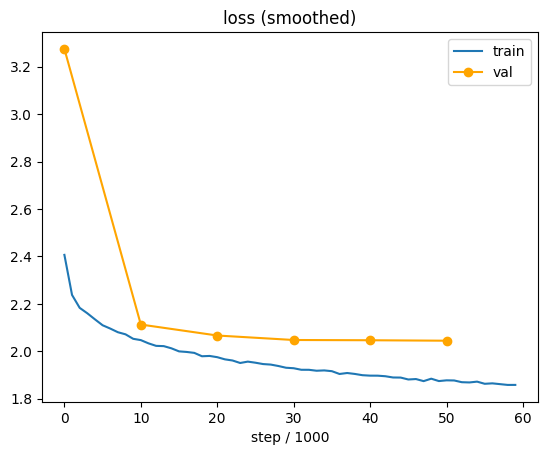

In [78]:
# smoothed training loss (mean of every 1000 steps) + val checkpoints
plt.plot(torch.stack(lossi).view(-1, 1000).mean(1).cpu(), label='train')

# val was recorded every 10000 steps -> rescale x into 'step / 1000' units
val_x = [k * 10 for k in range(len(val_lossi))]
plt.plot(val_x, torch.stack(val_lossi).cpu(), color='orange', marker='o', label='val')

plt.title('loss (smoothed)')
plt.xlabel('step / 1000')
plt.legend();

In [79]:
@torch.no_grad()
def split_loss(split):
    model.eval()
    x, y = {
        'train': (Xtr, Ytr),
        'val':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]
    x, y = x.to(device), y.to(device)
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('val')
split_loss('test')


val loss: 2.0614
test loss: 2.0553


In [83]:
@torch.no_grad()
def generate(n=20):
    model.eval()
    
    for _ in range(n):
        out = []
        context = [0] * block_size          # start with all '.'

        while True:
            x = torch.tensor([context], device=device)   # shape (1, block_size)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1).item()

            context = context[1:] + [ix]     # slide the window
            out.append(ix)

            if ix == 0:                      # hit the '.' end token
                break

        print(''.join(itos[i] for i in out[:-1]))   # drop trailing '.'


generate(20)


argelin
behdon
umyastin
ashloul
kaleis
jairen
zakira
jerion
jemah
demi
cantevahni
meage
amulya
gsaasim
aileyaa
gwinelle
million
hayzlee
payson
mikah


# Wavenet

In [143]:
# build the dataset
block_size = 8

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [175]:
n_embed = 12
n_hidden = 128


class Embedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.C = nn.Parameter(torch.randn(num_embeddings, embedding_dim))

    def forward(self, idx):
        return self.C[idx]


class FlattenConsecutive(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def forward(self, x):
        B, T, C = x.shape
        x = x.reshape(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        return x


class BatchNorm1d(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.bn = nn.BatchNorm1d(num_features)
    
    def forward(self, x):
        B, T, C = x.shape
        return self.bn(x.reshape(B*T, C)).reshape(B, T, C)



class WaveNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(                             # Assuming: n_embed = 10 and n_hidden = 64
            Embedding(vocab_size, n_embed),                      # (B, 8, 10)
            FlattenConsecutive(2),                               # (B, 4, 20)
            nn.Linear(n_embed * 2, n_hidden, bias=False),        # (B, 4, 20) @ (20, 64) -> (B, 4, 64)
            BatchNorm1d(n_hidden),                               # (B, 4, 64)
            nn.Tanh(),                                           # (B, 4, 64)

            FlattenConsecutive(2),                               # (B, 4, 64) -> (B, 2, 128)
            nn.Linear(n_hidden * 2, n_hidden, bias=False),       # (B, 2, 128) @ (128, 64) -> (B, 2, 64)
            BatchNorm1d(n_hidden),                               # (B, 2, 64)
            nn.Tanh(),                                           # (B, 2, 64)

            FlattenConsecutive(2),                               # (B, 2, 64) -> (B, 1, 128) -> (B, 128)
            nn.Linear(n_hidden * 2, vocab_size, bias=False),     # (B, 128) @ (128, 27) -> (B, 27)
        )

        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            self.layers[-1].weight *= 0.1

    def forward(self, idx):
        return self.layers(idx)

In [176]:
Xtr, Ytr = Xtr.to(device), Ytr.to(device)
Xdev, Ydev = Xdev.to(device), Ydev.to(device)

In [177]:
wavenet_model = WaveNet().to(device)
optimizer = torch.optim.SGD(wavenet_model.parameters(), lr=0.1)
sum(p.numel() for p in wavenet_model.parameters())

43588

In [178]:
max_steps = 200000
batch_size = 64
lossi = []
val_lossi = []


for i in range(max_steps):
    wavenet_model.train()
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward
    logits = wavenet_model(Xb) 
    loss = F.cross_entropy(logits, Yb)

    # backward
    optimizer.zero_grad()
    loss.backward()

    # update
    optimizer.step()

    # Update lr
    lr = 0.1 if i < 100000 else 0.04
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # track loss
    lossi.append(loss.detach())

    # stats
    if i % 10000 == 0 or i == max_steps - 1:
        window = lossi[-10000:]
        avg_loss = sum(window) / len(window)

        wavenet_model.eval()
        with torch.no_grad():
            val_loss = F.cross_entropy(wavenet_model(Xdev), Ydev)
        
        val_lossi.append(val_loss.detach())
        
        print(f'{i:7d}/{max_steps:7d}: Loss: {avg_loss:.4f}  Val: {val_loss:.4f}')  

      0/ 200000: Loss: 3.2932  Val: 3.2695
  10000/ 200000: Loss: 2.1567  Val: 2.1183
  20000/ 200000: Loss: 2.0466  Val: 2.0782
  30000/ 200000: Loss: 2.0089  Val: 2.0788
  40000/ 200000: Loss: 1.9850  Val: 2.0609
  50000/ 200000: Loss: 1.9664  Val: 2.0615
  60000/ 200000: Loss: 1.9564  Val: 2.0481
  70000/ 200000: Loss: 1.9428  Val: 2.0534
  80000/ 200000: Loss: 1.9343  Val: 2.0595
  90000/ 200000: Loss: 1.9263  Val: 2.0464
 100000/ 200000: Loss: 1.9191  Val: 2.0572
 110000/ 200000: Loss: 1.8733  Val: 2.0236
 120000/ 200000: Loss: 1.8705  Val: 2.0214
 130000/ 200000: Loss: 1.8681  Val: 2.0246
 140000/ 200000: Loss: 1.8663  Val: 2.0231
 150000/ 200000: Loss: 1.8646  Val: 2.0249
 160000/ 200000: Loss: 1.8605  Val: 2.0211
 170000/ 200000: Loss: 1.8579  Val: 2.0305
 180000/ 200000: Loss: 1.8558  Val: 2.0299
 190000/ 200000: Loss: 1.8540  Val: 2.0341
 199999/ 200000: Loss: 1.8504  Val: 2.0303


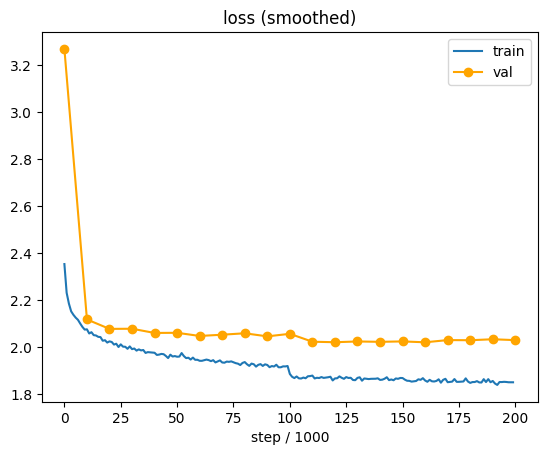

In [179]:
# smoothed training loss (mean of every 1000 steps) + val checkpoints
plt.plot(torch.stack(lossi).view(-1, 1000).mean(1).cpu(), label='train')

# val was recorded every 10000 steps -> rescale x into 'step / 1000' units
val_x = [k * 10 for k in range(len(val_lossi))]
plt.plot(val_x, torch.stack(val_lossi).cpu(), color='orange', marker='o', label='val')

plt.title('loss (smoothed)')
plt.xlabel('step / 1000')
plt.legend();

In [180]:
@torch.no_grad()
def split_loss(split):
    wavenet_model.eval()
    x, y = {
        'train': (Xtr, Ytr),
        'val':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]
    x, y = x.to(device), y.to(device)
    logits = wavenet_model(x)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('val')
split_loss('test')


val loss: 2.0303
test loss: 2.0192


In [186]:
@torch.no_grad()
def generate(n=20):
    wavenet_model.eval()
    
    for _ in range(n):
        out = []
        context = [0] * block_size          # start with all '.'

        while True:
            x = torch.tensor([context], device=device)   # shape (1, block_size)
            logits = wavenet_model(x)
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1).item()

            context = context[1:] + [ix]     # slide the window
            out.append(ix)

            if ix == 0:                      # hit the '.' end token
                break

        print(''.join(itos[i] for i in out[:-1]))   # drop trailing '.'


generate(20)


jalaynar
jerrel
jamee
lyah
kobett
paiyahnastas
fava
ayson
sinclayra
kimuan
capoti
zammadala
keyan
ibrata
jhalynn
lexus
yashe
dallore
andrina
katileean
